In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, AdaBoostRegressor, RandomForestRegressor
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load processed dataset

In [2]:
X_train = pd.read_csv('FIFA_Binary_Cleaned_Final_Train.csv')
X_test = pd.read_csv('FIFA_Binary_Cleaned_Final_Test.csv')

In [3]:
target_column = 'overall_binary' 

y_train = X_train[target_column]
X_train = X_train.drop(columns=[target_column])

y_test = X_test[target_column]
X_test = X_test.drop(columns=[target_column])

# Anomaly Detection methods

In [4]:
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train)
X_train_pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])

In [5]:
iso = IsolationForest(contamination=0.05, random_state=42).fit_predict(X_train_pca_df)

In [6]:
knn_dist, _ = NearestNeighbors(n_neighbors=5).fit(X_train_pca_df).kneighbors(X_train_pca_df)
knn_anoms = knn_dist[:, -1] > np.percentile(knn_dist[:, -1], 95)

In [7]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05).fit_predict(X_train_pca_df)

In [8]:
total_anomalies = (iso == -1).astype(int) + knn_anoms.astype(int) + (lof == -1).astype(int)
mask = total_anomalies < 2

In [9]:
X_train_refined = X_train[mask].reset_index(drop=True)
y_train_refined = y_train[mask].reset_index(drop=True)

print(f"Refined Data: {len(X_train_refined)} players remain.")

Refined Data: 13938 players remain.


# Visualising anomalies

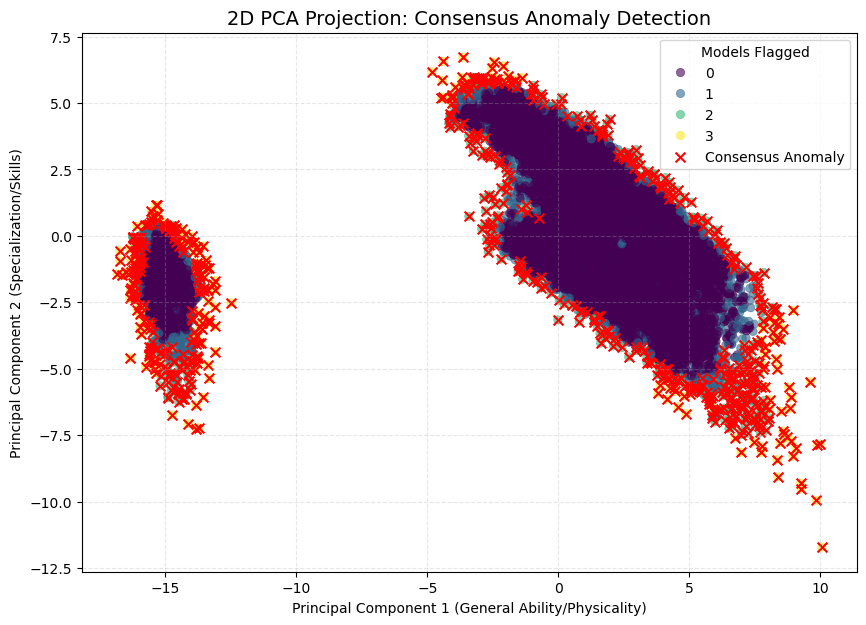

In [10]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], 
                hue=total_anomalies, 
                palette='viridis', 
                alpha=0.6, 
                edgecolor=None)

anomalies_idx = np.where(total_anomalies >= 2)
plt.scatter(X_train_pca[anomalies_idx, 0], X_train_pca[anomalies_idx, 1], 
            color='red', label='Consensus Anomaly', s=50, marker='x')

plt.title('2D PCA Projection: Consensus Anomaly Detection', fontsize=14)
plt.xlabel('Principal Component 1 (General Ability/Physicality)')
plt.ylabel('Principal Component 2 (Specialization/Skills)')
plt.legend(title='Models Flagged')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

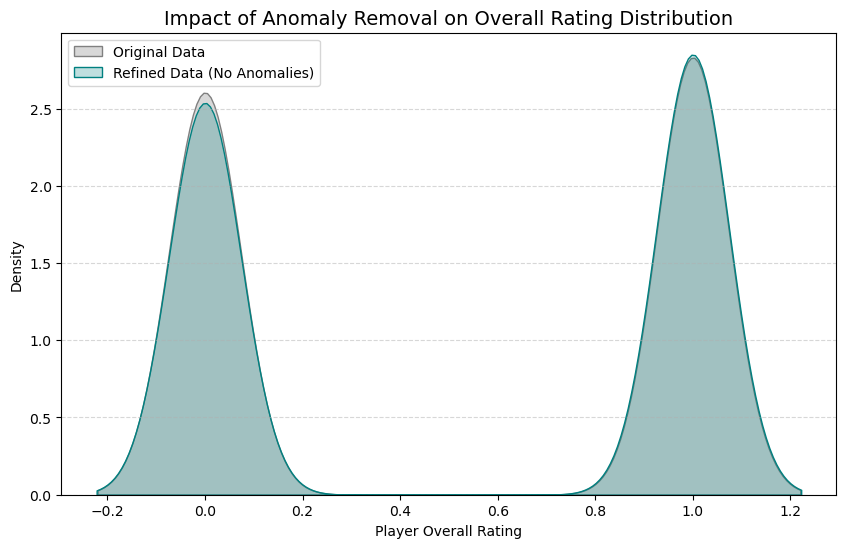

In [11]:
plt.figure(figsize=(10, 6))

sns.kdeplot(y_train, label='Original Data', fill=True, color="gray", alpha=0.3)
sns.kdeplot(y_train_refined, label='Refined Data (No Anomalies)', fill=True, color="teal")

plt.title('Impact of Anomaly Removal on Overall Rating Distribution', fontsize=14)
plt.xlabel('Player Overall Rating')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [12]:
print(X_train.columns.tolist())

['age', 'height_cm', 'weight_kg', 'nationality', 'club', 'potential', 'player_positions', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'team_position', 'team_jersey_number', 'loaned_from', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentali

# Recursive Feature Elimination (RFE)

In [13]:
from sklearn.metrics import r2_score

X_train_iter = X_train_refined.copy()
X_test_iter = X_test.copy()
remaining_features = X_train_iter.columns.tolist()

best_r2 = 0
best_features_list = []
history = []

print(f"{'Features':<10} | {'R2 Score':<10} | {'Removed Feature'}")
print("-" * 55)

while len(remaining_features) > 1:
    model = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=12, random_state=42),
        n_estimators=50,
        random_state=42
    )
    model.fit(X_train_iter, y_train_refined)
    y_pred = model.predict(X_test_iter)
    
    r2 = r2_score(y_test, y_pred)
    
    history.append((len(remaining_features), r2))
    
    if r2 > best_r2:
        best_r2 = r2
        best_features_list = remaining_features.copy()

    importances = model.feature_importances_
    least_important_idx = np.argmin(importances)
    removed_feature = remaining_features[least_important_idx]
    
    print(f"{len(remaining_features):<10} | {r2:<10.4f} | {removed_feature}")
    
    remaining_features.remove(removed_feature)
    X_train_iter = X_train_iter[remaining_features]
    X_test_iter = X_test_iter[remaining_features]

print("\n" + "="*50)
print(" ✅ Optimization Finished!")
print(f" Best R2 Score: {best_r2:.4f}")
print(f" Final Feature Count: {len(best_features_list)}")
print("="*50)

Features   | R2 Score   | Removed Feature
-------------------------------------------------------
73         | 0.9292     | international_reputation
72         | 0.9336     | num_positions
71         | 0.9283     | nation_position
70         | 0.9285     | player_tags_count
69         | 0.9262     | nation_jersey_number
68         | 0.9276     | skill_moves
67         | 0.9243     | real_face_Yes
66         | 0.9238     | gk_speed
65         | 0.9285     | preferred_foot_Right
64         | 0.9285     | gk_kicking
63         | 0.9259     | body_type
62         | 0.9314     | player_traits_count
61         | 0.9240     | weak_foot
60         | 0.9299     | joined_month
59         | 0.9289     | work_rate
58         | 0.9246     | dribbling
57         | 0.9248     | gk_handling
56         | 0.9262     | pace
55         | 0.9213     | gk_positioning
54         | 0.9222     | gk_diving
53         | 0.9340     | joined_year
52         | 0.9247     | contract_valid_until
51         | 0.9249  

# Model comparaison before anomaly detection and after

In [14]:

baseline_reg = AdaBoostRegressor(random_state=42)
baseline_reg.fit(X_train, y_train)
baseline_r2 = r2_score(y_test, baseline_reg.predict(X_test))

print("\n--- FINAL REGRESSION SUMMARY ---")
print(f"The Model R2 before anomaly detection: {baseline_r2:.16f}")
print(f"After Removal of anomalies & Selection: {best_r2:.4f}")
print(f"Total Features used: {len(best_features_list)}")


--- FINAL REGRESSION SUMMARY ---
The Model R2 before anomaly detection: 0.7963723128316378
After Removal of anomalies & Selection: 0.9405
Total Features used: 45


# Model comparaison on refined dataset to identify better R2 square

--- Regression Model Performance Comparison ---

AdaBoost Results:
R2 Score: 0.9333
Mean Absolute Error: 0.02 points

Random Forest Results:
R2 Score: 0.9208
Mean Absolute Error: 0.04 points


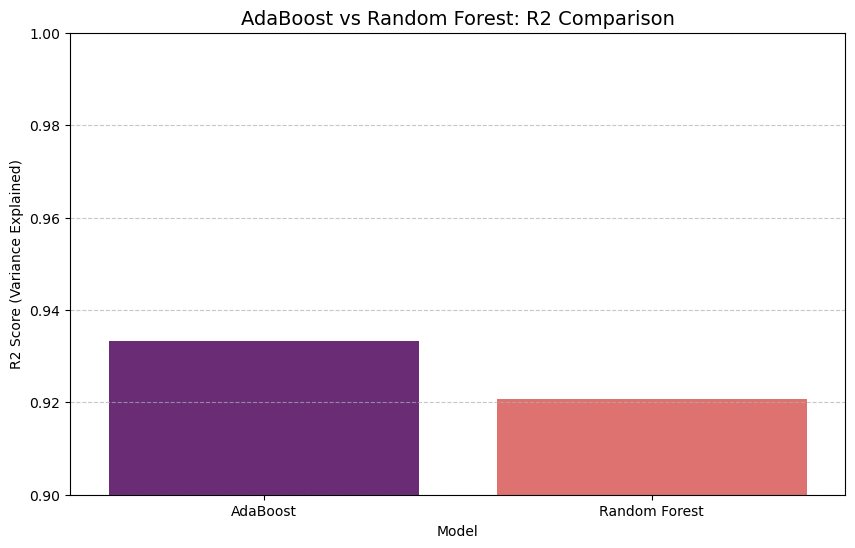

In [15]:

reg_models = {
    "AdaBoost": AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=12, random_state=42),
        n_estimators=100,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, 
        max_depth=15, 
        random_state=42
    )
}

results = []

print("--- Regression Model Performance Comparison ---")

for name, model in reg_models.items():
    model.fit(X_train_refined[best_features_list], y_train_refined)
    
    y_pred = model.predict(X_test[best_features_list])
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })
    
    print(f"\n{name} Results:")
    print(f"R2 Score: {r2:.4f}")
    print(f"Mean Absolute Error: {mae:.2f} points")

comparison_df = pd.DataFrame(results).set_index("Model")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_df.reset_index(), 
    x='Model', 
    y='R2 Score', 
    hue='Model',      
    palette='magma', 
    legend=False       
)

plt.title('AdaBoost vs Random Forest: R2 Comparison', fontsize=14)
plt.ylim(0.9, 1.0)      # Zooming in to show the high-performance differences
plt.ylabel('R2 Score (Variance Explained)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
best_model_reg = reg_models["AdaBoost"]
y_pred_final = best_model_reg.predict(X_test[best_features_list])
residuals = y_test - y_pred_final

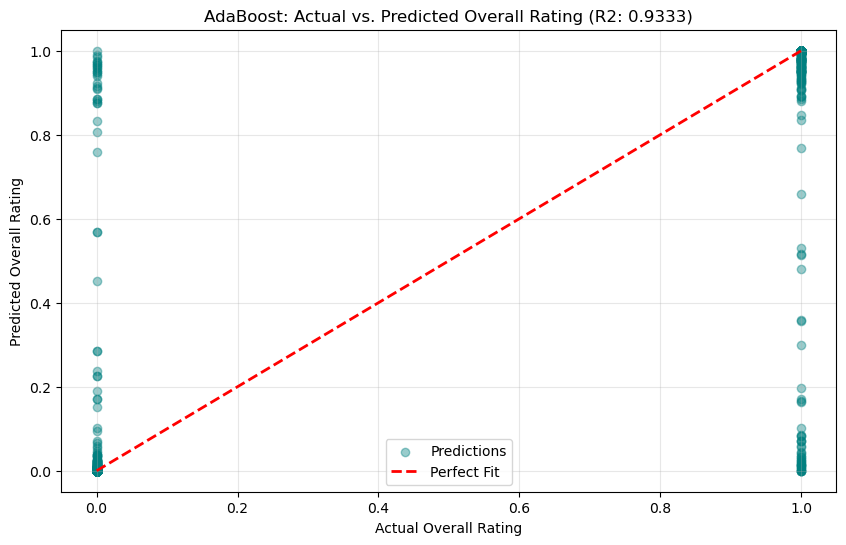

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.4, color='teal', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title(f'AdaBoost: Actual vs. Predicted Overall Rating (R2: {comparison_df.loc["AdaBoost", "R2 Score"]:.4f})')
plt.xlabel('Actual Overall Rating')
plt.ylabel('Predicted Overall Rating')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

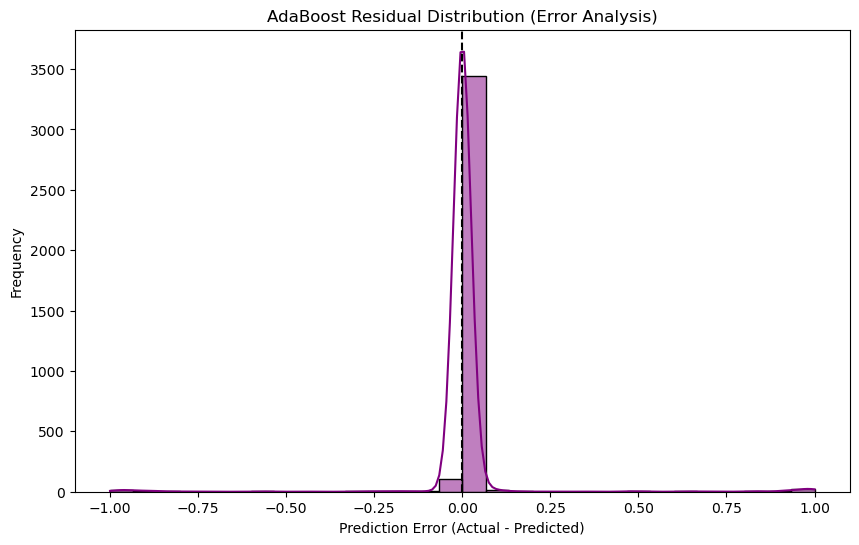

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('AdaBoost Residual Distribution (Error Analysis)')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

In [19]:
print("\n" + "="*50)
print(" ✅ Optimization Finished!")
print(f" Best R2 Score: {comparison_df.loc['AdaBoost', 'R2 Score']:.4f}")
print(f" Final Feature Count: {len(best_features_list)}")
print("="*50)


 ✅ Optimization Finished!
 Best R2 Score: 0.9333
 Final Feature Count: 45


# Feature importance and shap based on best model R2 sqaure

Calculating SHAP values for Random Forest (High-Speed TreeExplainer)...


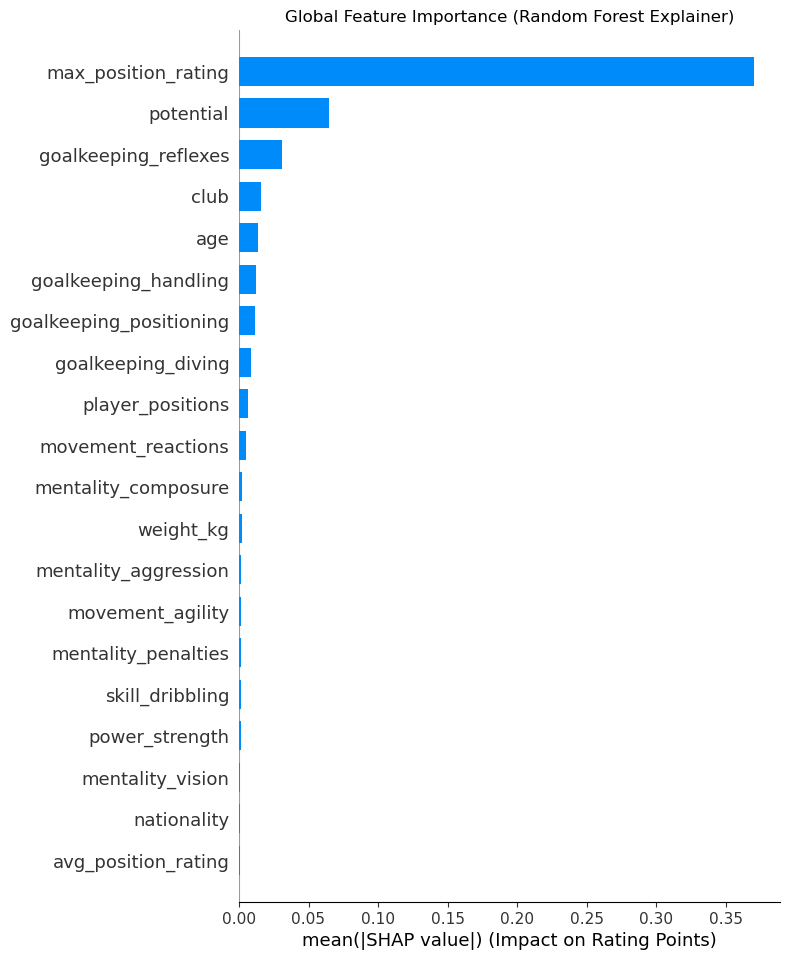

In [20]:
print("Calculating SHAP values for Random Forest (High-Speed TreeExplainer)...")

X_test_subset = X_test[best_features_list]

rf_model = reg_models["Random Forest"]
explainer = shap.TreeExplainer(rf_model)
target_shap = explainer.shap_values(X_test_subset)

plt.figure(figsize=(10, 6))
shap.summary_plot(target_shap, X_test_subset, plot_type="bar", show=False)
plt.title("Global Feature Importance (Random Forest Explainer)")
plt.xlabel("mean(|SHAP value|) (Impact on Rating Points)")
plt.savefig('shap_feature_importance_bar_reg.png', bbox_inches='tight')
plt.show()

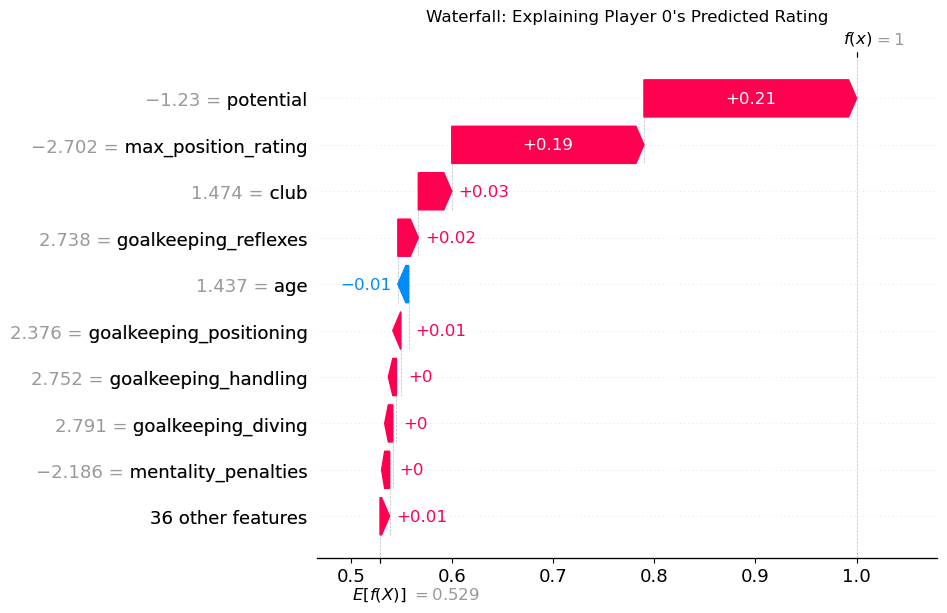

In [21]:
try:
   
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[0]
    else:
        base_val = explainer.expected_value

    plt.figure(figsize=(12, 8))
  
    exp = shap.Explanation(
        values=target_shap[0],
        base_values=base_val,
        data=X_test_subset.iloc[0],
        feature_names=X_test_subset.columns.tolist()
    )
    shap.plots.waterfall(exp, show=False)
    plt.title("Waterfall: Explaining Player 0's Predicted Rating")
    plt.savefig('shap_waterfall_reg.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Waterfall plot failed: {e}")

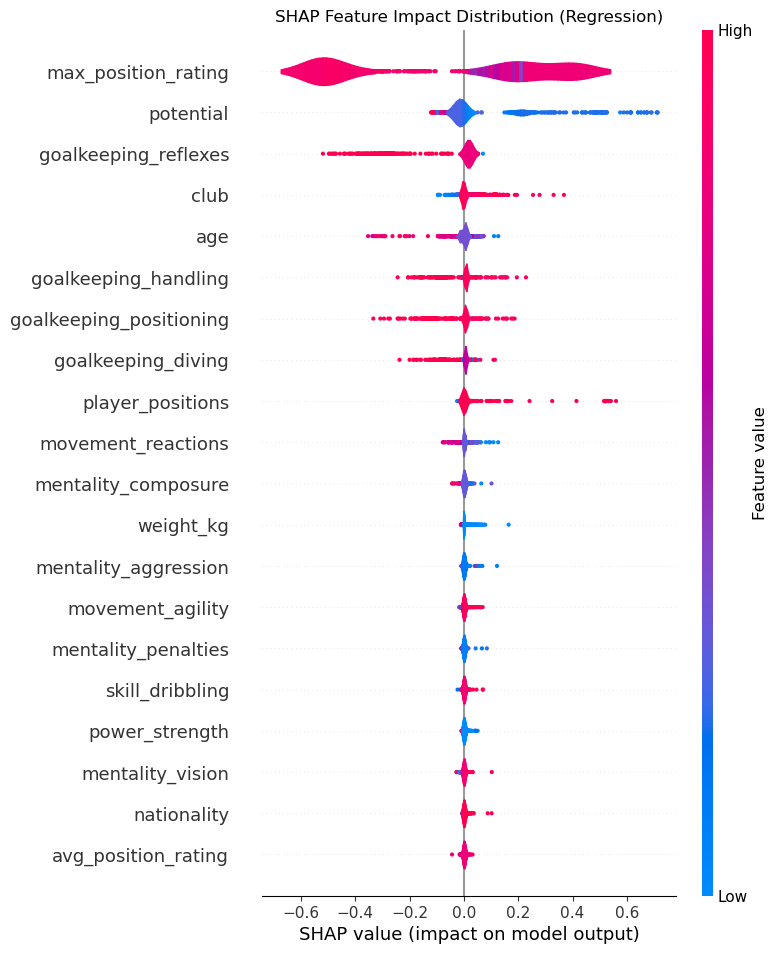

In [22]:
plt.figure(figsize=(10, 6))
shap.summary_plot(target_shap, X_test_subset, plot_type="violin", show=False)
plt.title("SHAP Feature Impact Distribution (Regression)")
plt.savefig('shap_violin_standard_reg.png', bbox_inches='tight')
plt.show()